In [1]:
import numpy as np
import glob, os
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
base_dict = {"VAE_RMSD": None,
             "VAE_LOSS_RMSD": None,
             "PCA_RMSD": None,
             "PCA_LOSS_RMSD": None}

def load_files(numpy_files, verbose=True):
    fns = sorted(numpy_files)
    attrs = [fn.split('/') for fn in fns]
    model_name = attrs[0][0]
    assert False not in [elem[0] == model_name for elem in attrs]
    
    model_data = {}
    for attr_set in attrs:
        n_latents = int(attr_set[1].split('_')[0])
        if n_latents not in model_data.keys():
            model_data[n_latents] = {}
        rpt = attr_set[2]
        if rpt not in model_data[n_latents].keys():
            model_data[n_latents][rpt] = deepcopy(base_dict)

        try:
            if attr_set[-1].split('.')[0] in [key for key in base_dict.keys()]:
                model_data[n_latents][rpt][attr_set[-1].split('.')[0]] = np.load(os.path.join(*attr_set))
            else:
                if verbose:
                    print(f"Excluding ", os.path.join(*attr_set))
        except:
            if verbose:
                    print(f"Failure on", os.path.join(*attr_set))
            
    return model_data

def lowest_rpts(chart_data):
    means = {}

    for key, val in chart_data.items():
        if key not in means.keys():
            means[key] = {}
        for key2, val2 in chart_data[key].items():
            if key2 not in means[key].keys():
                means[key][key2] = {}
            for key3, val3 in chart_data[key][key2].items():
                means[key][key2][key3] = np.mean(chart_data[key][key2][key3])
    
    best_rpts_RMSD = {key: None for key in means.keys()}
    best_rpts_LOSS = {key: None for key in means.keys()}
    
    for key, val in means.items():
        #discover the lowest mean rpt
        best_rpts_RMSD[key] = min(val.items(), key=lambda x: x[-1]['VAE_RMSD'])[0]
        best_rpts_LOSS[key] = min(val.items(), key=lambda x: x[-1]['VAE_LOSS_RMSD'])[0]
    
    return means, best_rpts_RMSD, best_rpts_LOSS

In [3]:
#Plot Violin of the best

def violin_plots(vae_dat, pca_dat, latents, title, ceil=5.0, show=False):
    import matplotlib.pyplot as plt
    
    plt.clf()
    fig = plt.figure(figsize=(3.25, 3.25))
    #rmsds and pca rmsds are a dict of results with keys n_latent and vals hist_vals
    rpt_rmsds = [10*vae_dat[key] for key in vae_dat.keys()] #convert to angstrom
    rpt_pca_rmsds = [10*pca_dat[key] for key in pca_dat.keys()] #convert to angstrom
    
    max_rmsd = np.max([np.max(rmsd_set) for rmsd_set in rpt_rmsds])
    if max_rmsd < ceil:
        ceil = max_rmsd + 0.1*max_rmsd
    
    v1 = plt.violinplot(rpt_rmsds, [np.log2(n)-0.05 for n in latents], showextrema=False)
    v2 = plt.violinplot(rpt_pca_rmsds, [np.log2(n)+0.05 for n in latents], showextrema=False)

    num_above = [val_set[np.where(val_set > ceil)].shape for val_set in rpt_rmsds]
    print(num_above)
    for i, b in enumerate(v1['bodies']):
        if not np.all(np.isnan(rpt_rmsds[i])):
            b.set_edgecolor('black')
            b.set_alpha(1)
            # get the center (the center is actually the domain point)
            m = np.mean(b.get_paths()[0].vertices[:, 0])
            # modify the paths to not go further right than the center
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
            b.set_color('r')
        else:
            plt.vlines(np.log2(latents[i])-0.05,
                       ymin=0.1,
                       ymax=ceil-1,
                       colors='red', linestyles='dashed')
            print(f'ALL VALUES ARE NAN FOR {latents[i]} LATENTS!')
    
    for b in v2['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further left than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
        b.set_color('b')
    
    plt.xlabel('N Latents (log2)')
    plt.ylabel('Reconstruction Error (Angstrom)')
    plt.title(title)
    plt.ylim(0, ceil)
    plt.savefig(os.path.join(figure_dir, f'reconstruction_rmsd_{title=}.png'), bbox_inches='tight')
    if show:
        plt.show()

In [4]:
def title_of_model(name):
    if name.startswith('OX_X'):
        return 'Oxycodone'
    elif name.startswith('DA_X'):
        return 'Deca-Alanine'
    elif name.startswith('DA_stretch'):
        return 'Deca-Alanine Helix Stretch'
    elif name.startswith('CR_X'):
        return 'Crambin'
    elif name.startswith('BR_X'):
        return 'BRD4/JQ1'
    elif name.startswith('HIV1p_X'):
        return 'HIV1-Protease'
    elif name.startswith('KOR_X'):
        return 'KOR/ak'
    else:
        raise Exception(f'No title found for {name}!')

In [5]:
# base_models = [f'X009-{i}' for i in range(1, 7)]
# model_prefixes = ['OX_', 'DA_', 'CR_', 'BR_']

In [6]:
base_models, model_prefixes = ['X012-1'], ['OX_', 'DA_', 'DA_stretch_', 'CR_', 'BR_', 'KOR_']

OX_X012-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

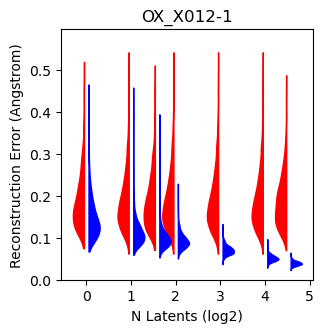

DA_X012-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

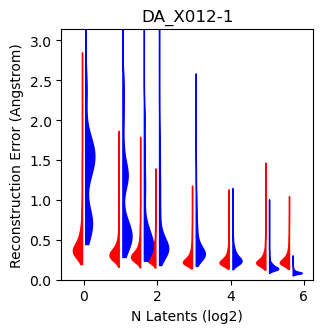

DA_stretch_X012-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

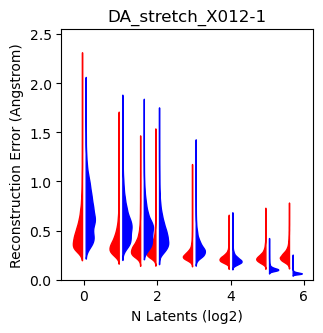

CR_X012-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

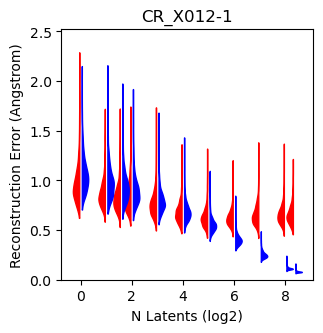

BR_X012-1
[(8,), (8,), (8,), (0,), (8,), (8,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

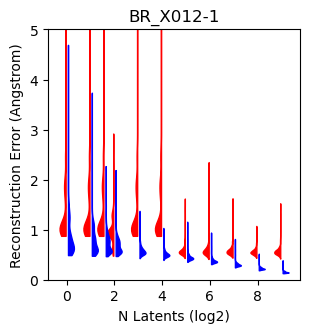

KOR_X012-1
[(0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,), (0,)]


<Figure size 640x480 with 0 Axes>

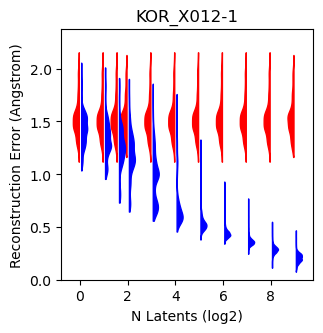

In [7]:
show = True

for base_model in base_models:
    for model_pre in model_prefixes:
        model_name2load = model_pre + base_model
        print(model_name2load)
        chart_data = load_files(glob.glob(f'{model_name2load}/*/*/*.npy'), verbose=False)
        means, best_rpts_rmsd, best_rpts_loss = lowest_rpts(chart_data)
        
        vae_rmsds =      {key: val[best_rpts_rmsd[key]]['VAE_RMSD']      for key, val in chart_data.items()}
        vae_loss_rmsds = {key: val[best_rpts_loss[key]]['VAE_LOSS_RMSD'] for key, val in chart_data.items()}
        pca_rmsds =      {key: val[best_rpts_rmsd[key]]['PCA_RMSD']      for key, val in chart_data.items()}
        pca_loss_rmsds = {key: val[best_rpts_loss[key]]['PCA_LOSS_RMSD'] for key, val in chart_data.items()}
        
        latents = [int(key) for key in vae_rmsds]
    
        figure_dir = os.path.join(os.getcwd(), f'figures/{model_name2load}/')
        if not os.path.isdir(figure_dir):
            os.makedirs(figure_dir, exist_ok=True)
        try:
            violin_plots(vae_rmsds, pca_rmsds, latents, model_name2load, show=True)
        except:
           print(f"Error Producing Plots on {model_name2load}")